# 04 — BOCPD Within Epoch (Windowed Variance)

BOCPD on **windowed variance** within the epoch. Temporal EDA (04) showed baseline < early < late variance—a clear regime shift. This notebook tests whether BOCPD detects that transition.

Uses log(variance + ε) for Gaussian-friendly scaling. Lower hazard (0.02) for sensitivity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from scipy.stats import norm

def logsumexp(x):
    m = np.max(x)
    return m + np.log(np.sum(np.exp(x - m)))

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else (Path.cwd() / ".." / "..").resolve()
DATA_ROOT = ROOT / "data"
ARTIFACTS_FIG = ROOT / "artifacts" / "figures" / "bocpd" / "within_epoch_variance"
ARTIFACTS_FIG.mkdir(parents=True, exist_ok=True)
WINDOW_SIZE = 10
STRIDE = 5
HAZARD = 0.02

In [2]:
def load_preprocessed(path):
    d = np.load(path, allow_pickle=True).item()
    return d["preprocessed_eeg_data"], d["ch_names"], d["times"]

def windowed_variance(trace, window_size=10, stride=5, log_scale=True):
    """trace: (n_ch, n_time). Returns (n_windows,) variance per window (channel-avg)."""
    if trace.ndim == 2:
        trace = trace.mean(axis=0)
    n = len(trace)
    windows = []
    for start in range(0, n - window_size + 1, stride):
        v = trace[start : start + window_size].var()
        windows.append(np.log(v + 1e-10) if log_scale else v)
    return np.array(windows)

def bocpd_gaussian(x, hazard=0.02, mean0=None, var0=1.0, varx=None):
    T = len(x)
    if mean0 is None:
        mean0 = np.mean(x)
    if varx is None:
        varx = np.var(x) + 1e-6
    prec0 = 1.0 / var0
    precx = 1.0 / varx
    log_H = np.log(hazard)
    log_1mH = np.log(1 - hazard)
    R = np.zeros((T + 1, T + 1))
    cp_prob = np.zeros(T)
    prec_params = np.array([prec0])
    mean_params = np.array([mean0])
    log_message = np.array([0.0])
    for t in range(T):
        xt = x[t]
        post_prec = prec_params[: t + 1]
        post_var = 1.0 / post_prec + varx
        post_std = np.sqrt(post_var)
        log_preds = norm.logpdf(xt, mean_params[: t + 1], post_std)
        log_growth = log_preds + log_message + log_1mH
        # CP: predict from prior (log_preds[0]); sum over prev run-lengths (Adams & MacKay)
        log_cp = log_preds[0] + log_H + logsumexp(log_message)
        new_log_joint = np.append(log_cp, log_growth)
        new_log_joint -= logsumexp(new_log_joint)
        R[t, : t + 2] = np.exp(new_log_joint)
        cp_prob[t] = np.exp(new_log_joint[0])
        new_prec = prec_params + precx
        prec_params = np.append([prec0], new_prec)
        new_mean = (mean_params * prec_params[:-1] + xt * precx) / new_prec
        mean_params = np.append([mean0], new_mean)
        log_message = new_log_joint
    return R[:T], cp_prob

## Load data and compute windowed variance (averaged ERP)

Variance ramps up post-stimulus (EDA 04). Expect BOCPD to flag transition near 0–200 ms.

sub-01: 19 windows, log_var mean=-7.635, std=0.769
Peak changepoint: 595 ms, prob=0.101


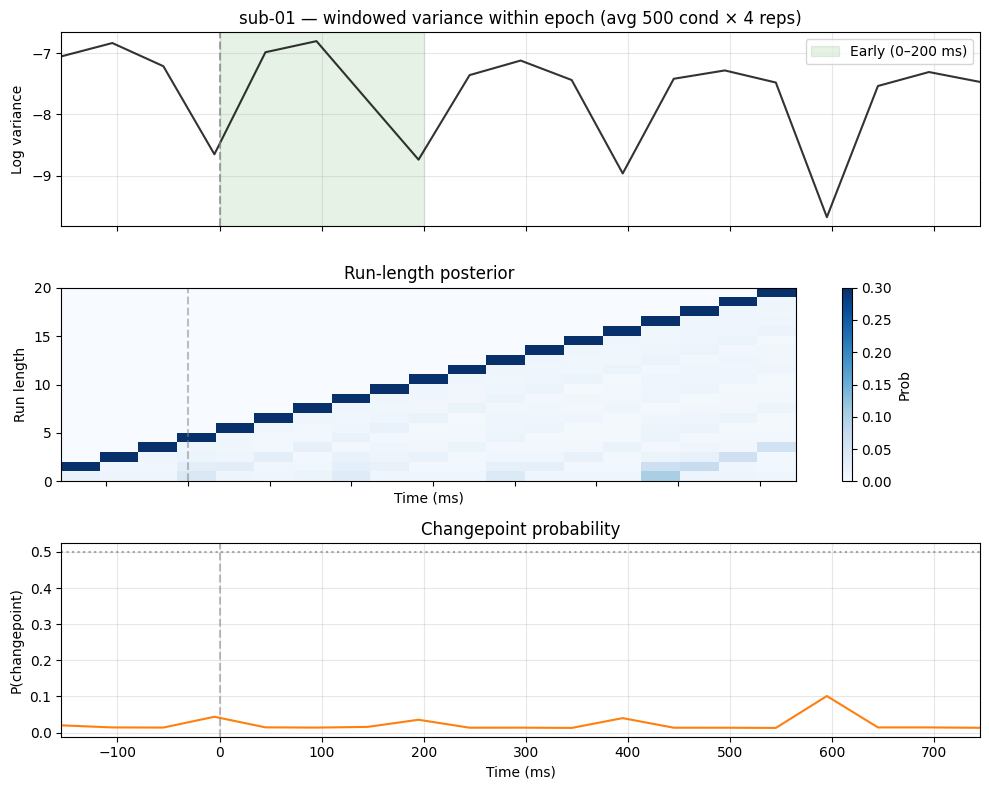

Saved bocpd__within_epoch_variance__sub-01__2026-02-27.png


sub-02: 19 windows, log_var mean=-7.796, std=0.692
Peak changepoint: 195 ms, prob=0.064


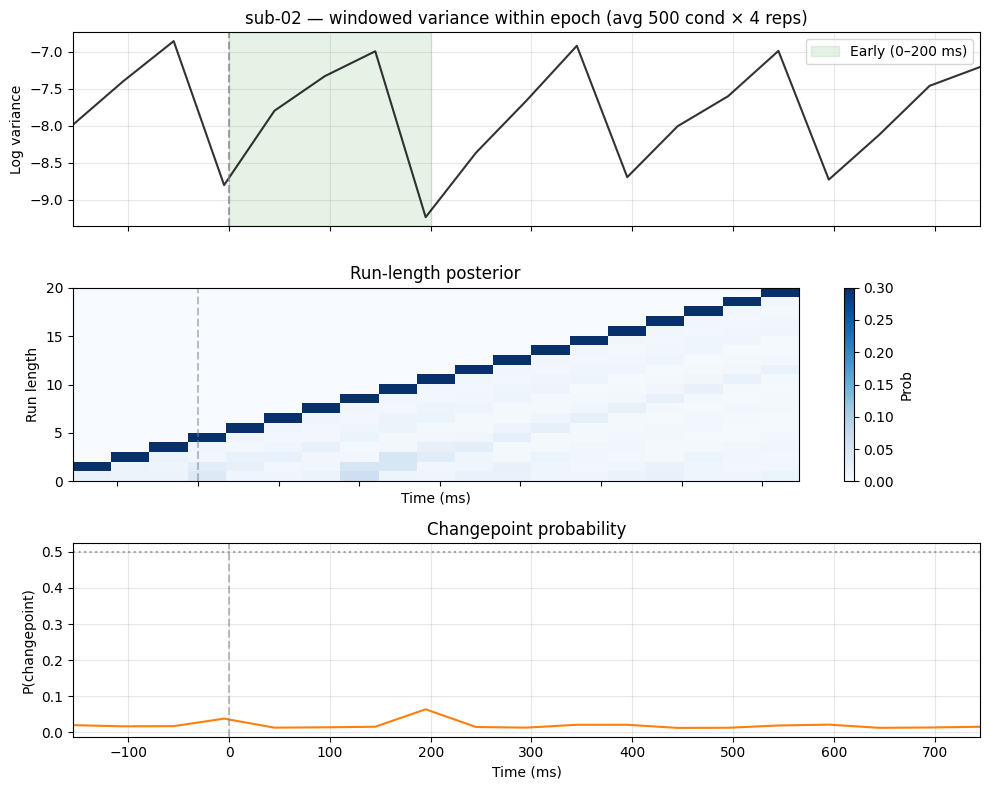

Saved bocpd__within_epoch_variance__sub-02__2026-02-27.png


sub-03: 19 windows, log_var mean=-6.443, std=0.367
Peak changepoint: 595 ms, prob=0.104


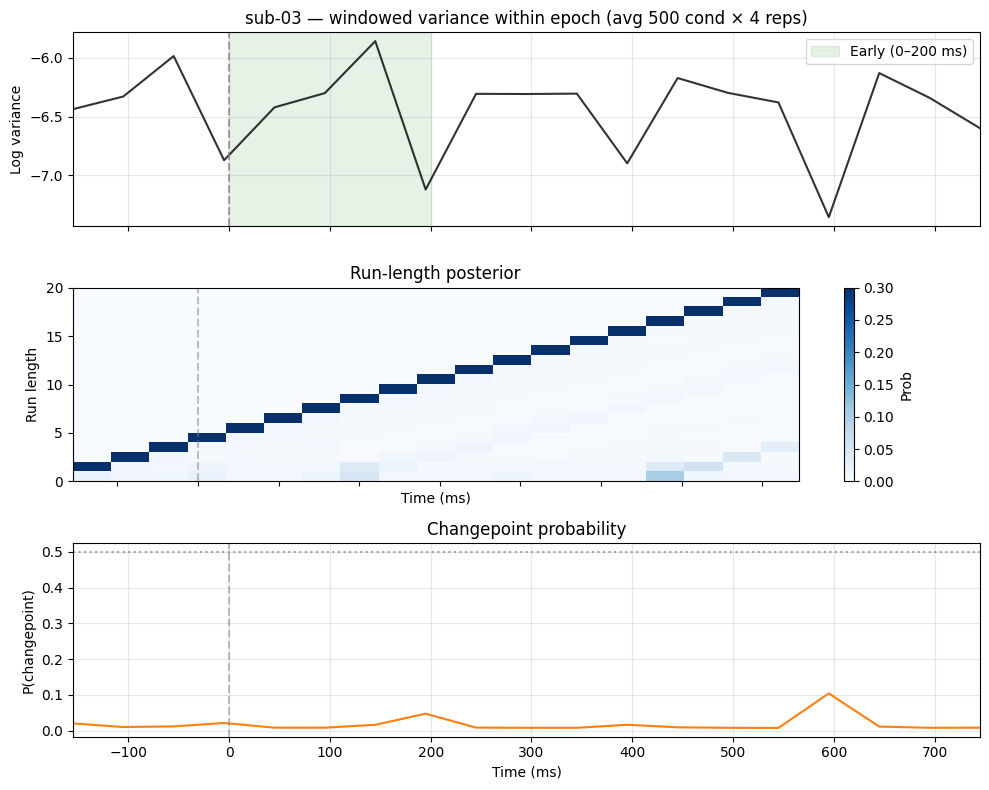

Saved bocpd__within_epoch_variance__sub-03__2026-02-27.png


sub-04: 19 windows, log_var mean=-7.591, std=0.451
Peak changepoint: 595 ms, prob=0.124


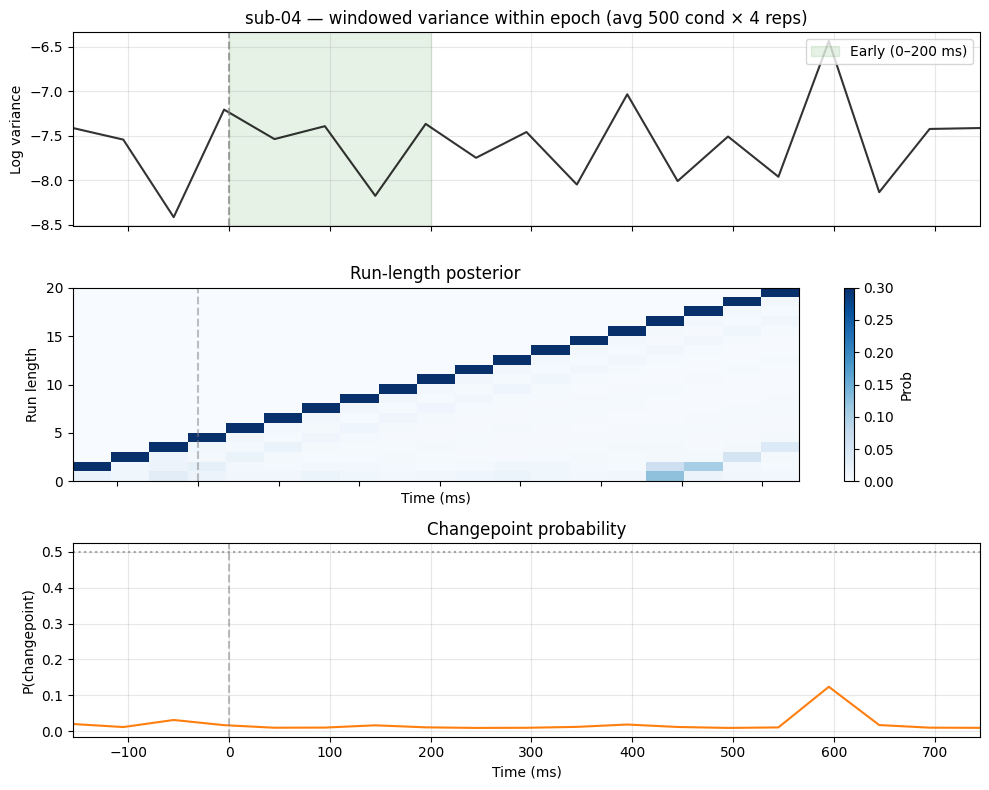

Saved bocpd__within_epoch_variance__sub-04__2026-02-27.png


sub-05: 19 windows, log_var mean=-6.524, std=0.394
Peak changepoint: 745 ms, prob=0.112


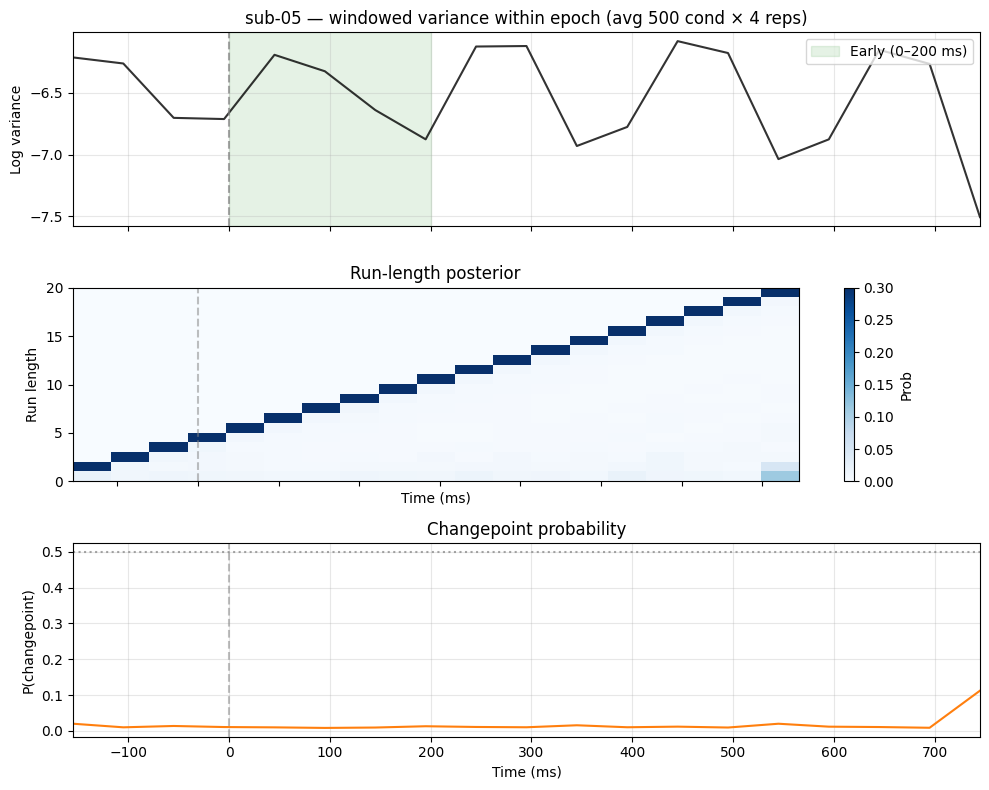

Saved bocpd__within_epoch_variance__sub-05__2026-02-27.png


sub-06: 19 windows, log_var mean=-7.108, std=0.953
Peak changepoint: 345 ms, prob=0.040


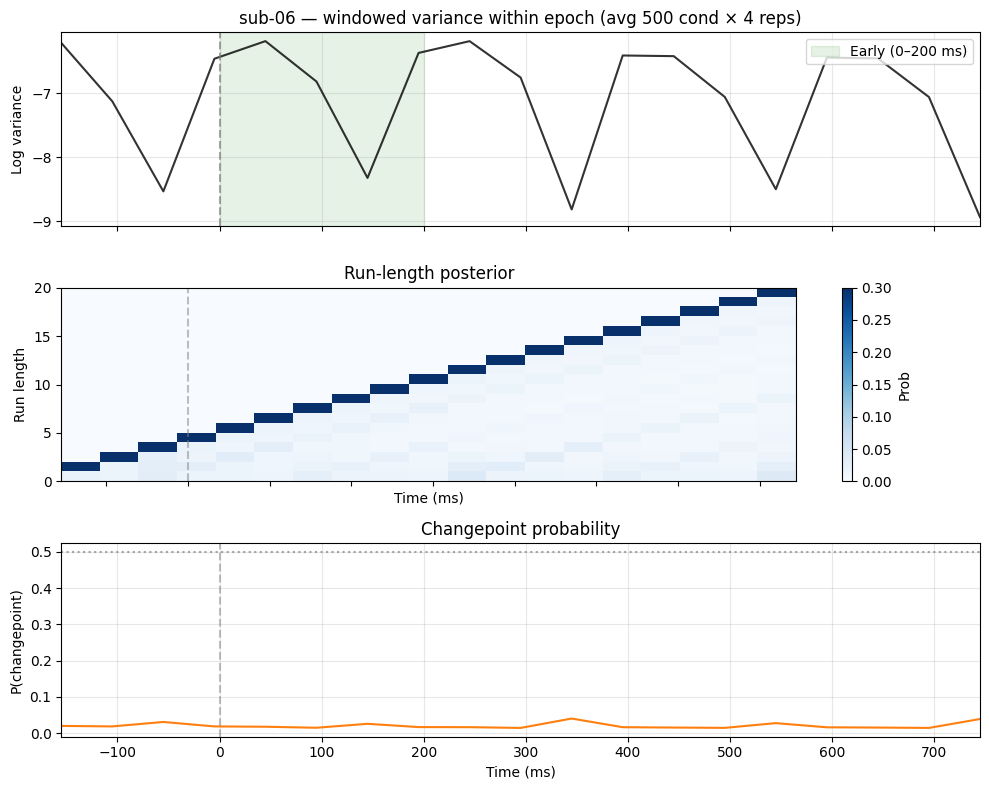

Saved bocpd__within_epoch_variance__sub-06__2026-02-27.png


sub-07: 19 windows, log_var mean=-6.473, std=0.740
Peak changepoint: 595 ms, prob=0.053


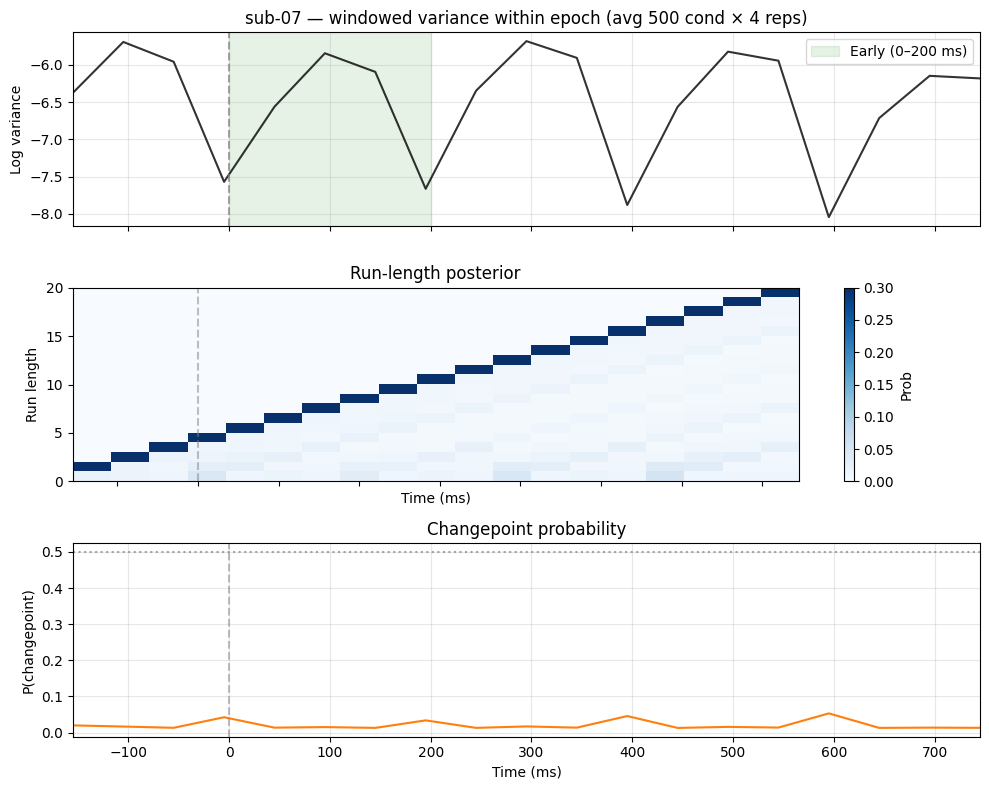

Saved bocpd__within_epoch_variance__sub-07__2026-02-27.png


sub-08: 19 windows, log_var mean=-6.271, std=0.720
Peak changepoint: 395 ms, prob=0.082


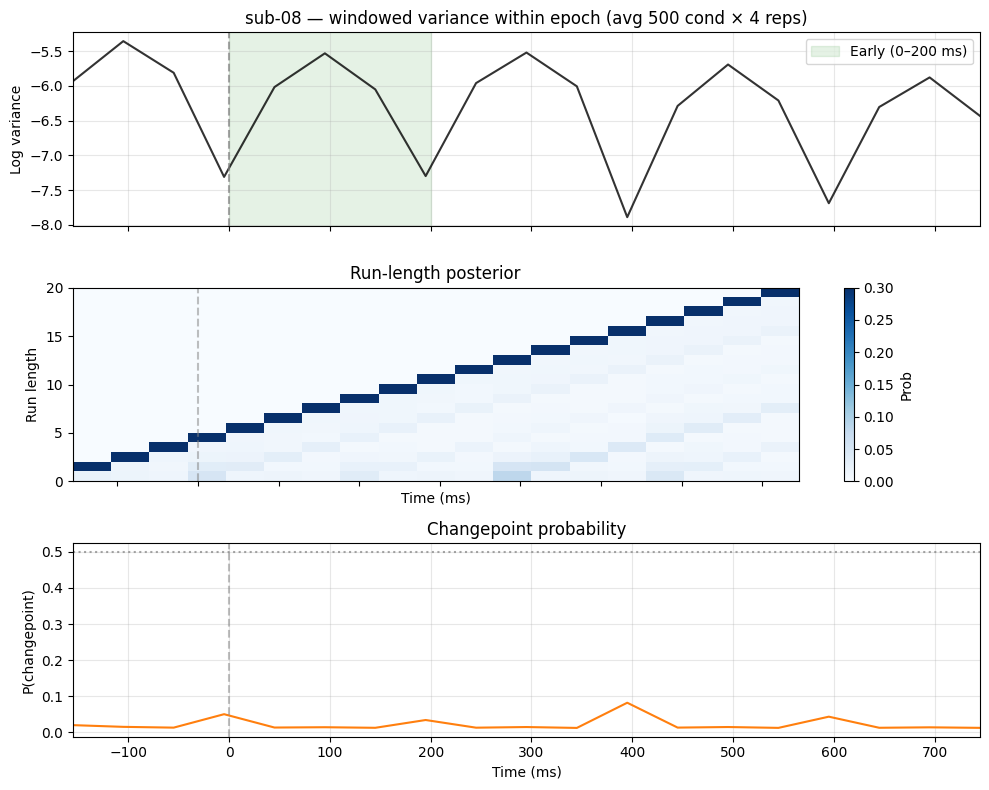

Saved bocpd__within_epoch_variance__sub-08__2026-02-27.png


sub-09: 19 windows, log_var mean=-8.010, std=0.667
Peak changepoint: 745 ms, prob=0.045


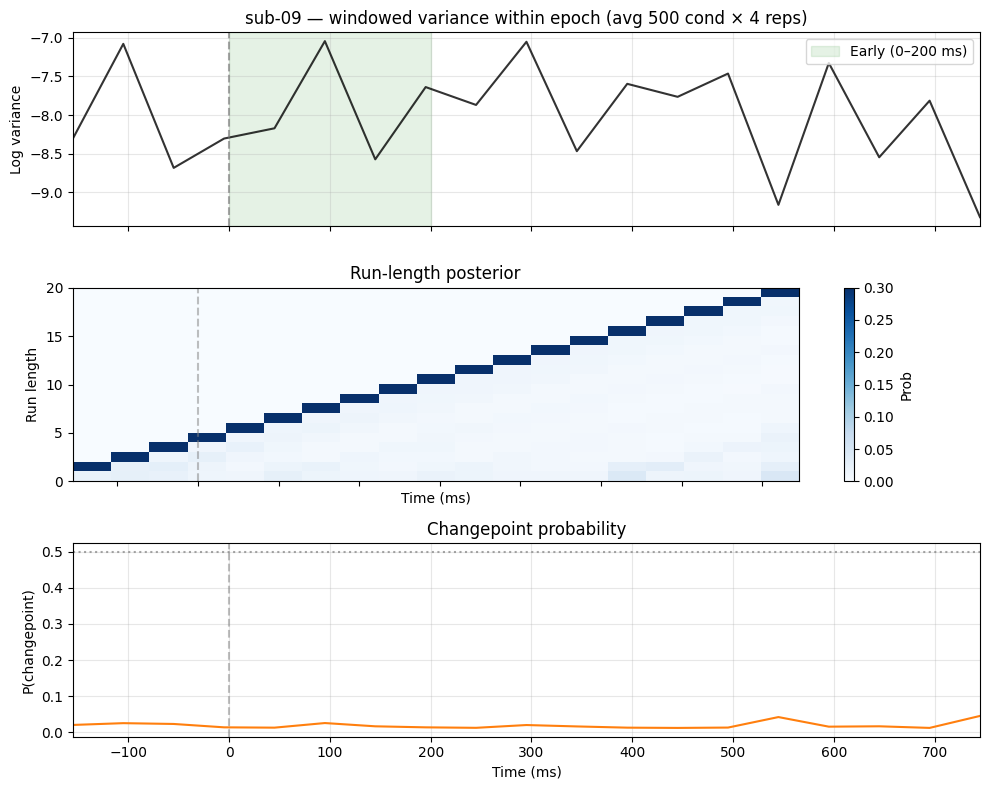

Saved bocpd__within_epoch_variance__sub-09__2026-02-27.png


sub-10: 19 windows, log_var mean=-6.790, std=0.610
Peak changepoint: 295 ms, prob=0.031


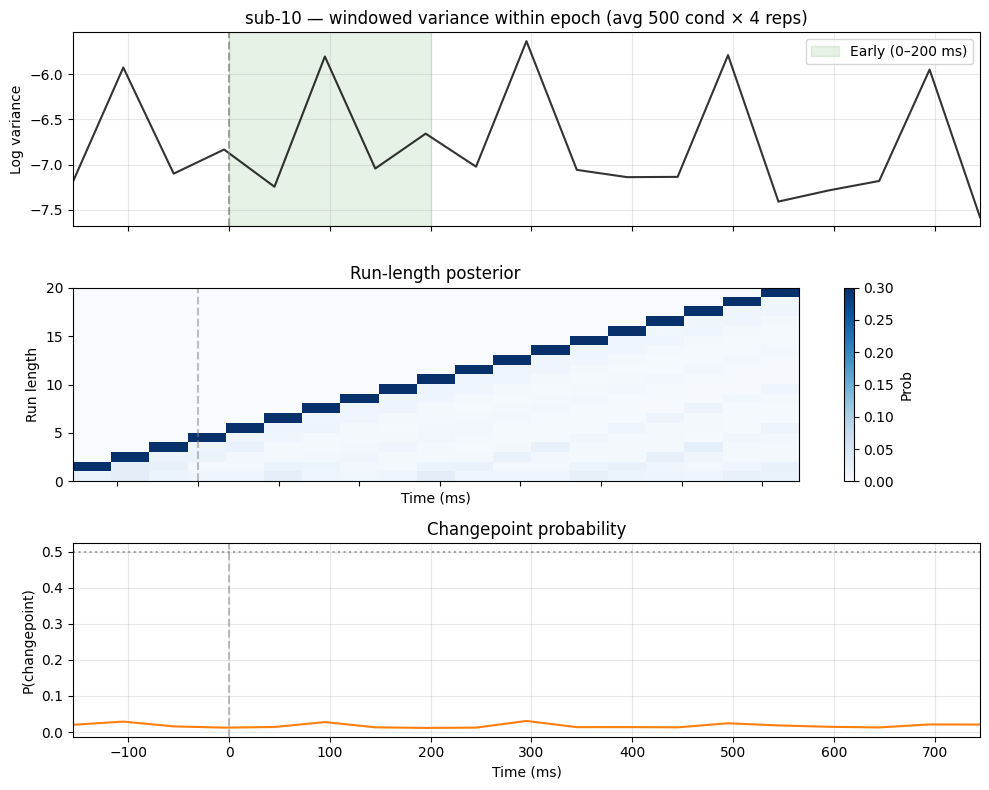

Saved bocpd__within_epoch_variance__sub-10__2026-02-27.png


In [3]:
n_cond_sample = 500
np.random.seed(42)
# Save figures for all 10 participants
for sub in [f"sub-{i:02d}" for i in range(1, 11)]:
    p = DATA_ROOT / sub / "preprocessed_eeg_training.npy"
    if not p.exists():
        continue
    X, ch_names, times = load_preprocessed(p)
    cond_idx = np.random.choice(X.shape[0], size=min(n_cond_sample, X.shape[0]), replace=False)
    erp = X[cond_idx].mean(axis=(0, 1))
    x = windowed_variance(erp, WINDOW_SIZE, STRIDE)
    window_centers_ms = ((np.arange(len(x)) * STRIDE + (WINDOW_SIZE - 1) / 2) * 10) - 200
    R, cp_prob = bocpd_gaussian(x, hazard=HAZARD)
    idx_peak = np.argmax(cp_prob)
    print(f"{sub}: {len(x)} windows, log_var mean={x.mean():.3f}, std={x.std():.3f}")
    print(f"Peak changepoint: {window_centers_ms[idx_peak]:.0f} ms, prob={cp_prob[idx_peak]:.3f}")
    # Plot and save figure
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(window_centers_ms, x, "k-", alpha=0.8)
    axes[0].axvline(0, color="gray", ls="--", alpha=0.7)
    axes[0].axvspan(0, 200, alpha=0.1, color="green", label="Early (0–200 ms)")
    axes[0].set_ylabel("Log variance")
    axes[0].set_title(f"{sub} — windowed variance within epoch (avg {n_cond_sample} cond × 4 reps)")
    axes[0].legend(loc="upper right")
    axes[0].grid(True, alpha=0.3)
    im = axes[1].imshow(R.T[:, : len(x)], aspect="auto", origin="lower", cmap="Blues",
                        extent=[window_centers_ms[0], window_centers_ms[-1], 0, R.shape[1]], vmin=0, vmax=0.3)
    axes[1].axvline(0, color="gray", ls="--", alpha=0.5)
    axes[1].set_ylabel("Run length")
    axes[1].set_xlabel("Time (ms)")
    axes[1].set_title("Run-length posterior")
    plt.colorbar(im, ax=axes[1], label="Prob")
    axes[2].plot(window_centers_ms, cp_prob, "C1-", lw=1.5)
    axes[2].axvline(0, color="gray", ls="--", alpha=0.5)
    axes[2].axhline(0.5, color="gray", ls=":", alpha=0.7)
    axes[2].set_ylabel("P(changepoint)")
    axes[2].set_xlabel("Time (ms)")
    axes[2].set_title("Changepoint probability")
    axes[2].grid(True, alpha=0.3)
    plt.tight_layout()
    out_path = ARTIFACTS_FIG / f"bocpd__within_epoch_variance__{sub}__2026-02-27.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_path.name}")

## Plot: windowed variance, run-length posterior, changepoint probability

In [4]:
# Figures saved in loop above for all 10 participants.

## Peak changepoint latency (all participants)

In [5]:
rows = []
for sub in [f"sub-{i:02d}" for i in range(1, 11)]:
    p = DATA_ROOT / sub / "preprocessed_eeg_training.npy"
    if not p.exists():
        continue
    X, _, _ = load_preprocessed(p)
    cond_idx = np.random.choice(X.shape[0], size=min(500, X.shape[0]), replace=False)
    erp = X[cond_idx].mean(axis=(0, 1))
    x = windowed_variance(erp, WINDOW_SIZE, STRIDE)
    window_centers_ms = ((np.arange(len(x)) * STRIDE + (WINDOW_SIZE - 1) / 2) * 10) - 200
    _, cp_prob = bocpd_gaussian(x, hazard=HAZARD)
    idx_max = np.argmax(cp_prob)
    rows.append({
        "participant": sub,
        "peak_cp_ms": float(window_centers_ms[idx_max]),
        "max_cp_prob": float(cp_prob.max()),
    })
peak_df = pd.DataFrame(rows)
table_path = ROOT / "artifacts" / "tables" / "bocpd__within_epoch_variance_peak_latency__2026-02-27.csv"
table_path.parent.mkdir(parents=True, exist_ok=True)
peak_df.to_csv(table_path, index=False)
print(peak_df.to_string(index=False))
print(f"\nMean peak latency: {peak_df['peak_cp_ms'].mean():.0f} ms")

participant  peak_cp_ms  max_cp_prob
     sub-01       195.0     0.067086
     sub-02       195.0     0.046139
     sub-03       595.0     0.138486
     sub-04       145.0     0.073088
     sub-05       545.0     0.071002
     sub-06       145.0     0.055960
     sub-07       195.0     0.050300
     sub-08       395.0     0.070772
     sub-09        95.0     0.044719
     sub-10       295.0     0.030103

Mean peak latency: 280 ms


## Per-condition analysis

Run BOCPD on individual conditions (instead of averaging 500) to see if changepoint latency varies by image category.

In [6]:
np.random.seed(42)
n_cond_sample = 20
per_cond_rows = []
for sub in [f"sub-{i:02d}" for i in range(1, 4)]:
    p = DATA_ROOT / sub / "preprocessed_eeg_training.npy"
    if not p.exists():
        continue
    X, _, _ = load_preprocessed(p)
    cond_idx = np.random.choice(X.shape[0], size=min(n_cond_sample, X.shape[0]), replace=False)
    for c in cond_idx:
        erp = X[c].mean(axis=0)
        x = windowed_variance(erp, WINDOW_SIZE, STRIDE)
        window_centers_ms = ((np.arange(len(x)) * STRIDE + (WINDOW_SIZE - 1) / 2) * 10) - 200
        _, cp_prob = bocpd_gaussian(x, hazard=HAZARD)
        idx_max = np.argmax(cp_prob)
        per_cond_rows.append({"participant": sub, "condition": int(c), "peak_cp_ms": float(window_centers_ms[idx_max]), "max_cp_prob": float(cp_prob.max())})
per_cond_df = pd.DataFrame(per_cond_rows)
table_path = ROOT / "artifacts" / "tables" / "bocpd__within_epoch_variance_per_condition__2026-02-27.csv"
table_path.parent.mkdir(parents=True, exist_ok=True)
per_cond_df.to_csv(table_path, index=False)
print(per_cond_df.groupby("participant").agg({"peak_cp_ms": ["mean", "std"], "max_cp_prob": ["mean", "max"]}).round(2))
print(f"\nSaved {table_path.name}")

            peak_cp_ms         max_cp_prob      
                  mean     std        mean   max
participant                                     
sub-01           332.5  268.95        0.06  0.11
sub-02           317.5  269.25        0.07  0.20
sub-03           402.5  231.29        0.07  0.17

Saved bocpd__within_epoch_variance_per_condition__2026-02-27.csv
